# Análisis de Datos - Cáncer de Mama (Wisconsin Breast Cancer Dataset)

**Equipo:** Santiago Calle – Alexander Luna  - Alvaro Quisilema   
**Programa:** Maestría en Ciencia de Datos y Máquinas de Aprendizaje  
**Fecha:** 26 de mayo 2026

**Objetivo:**Predicción de cáncer4 de mama utilizando Regresión Logística y K-NN

---
## FASE I - Preprocesamiento de Datos

### 1. Importar librerías

In [1]:
# Librerías principales
import numpy as np
import pandas as pd

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Normalización
from sklearn.preprocessing import MinMaxScaler

# Configuración visual
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

### 2. Cargar el conjunto de datos

In [2]:
# URLs de los archivos CSV en GitHub
train_path = 'https://raw.githubusercontent.com/Alexander-Luna/UIDE-HERRAMIENTAS-PARA-DATA-SCIENCE/main/Semana1/Tarea/wdbc_train.csv'
test_path = 'https://raw.githubusercontent.com/Alexander-Luna/UIDE-HERRAMIENTAS-PARA-DATA-SCIENCE/main/Semana1/Tarea/wdbc_test.csv'

# Leer los archivos CSV
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print('--- Dataset de Entrenamiento (primeras 5 filas) ---')
print(df_train.head())
print(f'\nDimensiones: {df_train.shape}')

print('\n--- Dataset de Prueba (primeras 5 filas) ---')
print(df_test.head())
print(f'\nDimensiones: {df_test.shape}')

--- Dataset de Entrenamiento (primeras 5 filas) ---
         id diagnosis  radius1  texture1  perimeter1   area1  smoothness1  \
0    842302         M    17.99     10.38      122.80  1001.0      0.11840   
1    842517         M    20.57     17.77      132.90  1326.0      0.08474   
2  84300903         M    19.69     21.25      130.00  1203.0      0.10960   
3  84348301         M    11.42     20.38       77.58   386.1      0.14250   
4  84358402         M    20.29     14.34      135.10  1297.0      0.10030   

   compactness1  concavity1  concave_points1  ...  radius3  texture3  \
0       0.27760      0.3001          0.14710  ...    25.38     17.33   
1       0.07864      0.0869          0.07017  ...    24.99     23.41   
2       0.15990      0.1974          0.12790  ...    23.57     25.53   
3       0.28390      0.2414          0.10520  ...    14.91     26.50   
4       0.13280      0.1980          0.10430  ...    22.54     16.67   

   perimeter3   area3  smoothness3  compactness3  co

### 3. Entendimiento de los datos

In [3]:
# Información general del dataset de entrenamiento
print('=== INFORMACIÓN DEL DATASET DE ENTRENAMIENTO ===')
print(df_train.info())

print('\n=== INFORMACIÓN DEL DATASET DE PRUEBA ===')
print(df_test.info())

=== INFORMACIÓN DEL DATASET DE ENTRENAMIENTO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455 entries, 0 to 454
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  455 non-null    int64  
 1   diagnosis           455 non-null    object 
 2   radius1             455 non-null    float64
 3   texture1            455 non-null    float64
 4   perimeter1          455 non-null    float64
 5   area1               455 non-null    float64
 6   smoothness1         455 non-null    float64
 7   compactness1        455 non-null    float64
 8   concavity1          455 non-null    float64
 9   concave_points1     455 non-null    float64
 10  symmetry1           455 non-null    float64
 11  fractal_dimension1  455 non-null    float64
 12  radius2             455 non-null    float64
 13  texture2            455 non-null    float64
 14  perimeter2          455 non-null    float64
 15  area2   

In [4]:
# Estadísticas descriptivas del dataset de entrenamiento
print('=== ESTADÍSTICAS DESCRIPTIVAS (TRAIN) ===')
df_train.describe()

=== ESTADÍSTICAS DESCRIPTIVAS (TRAIN) ===


,id,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,4.550000e+02,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,...,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000
mean,2.713560e+07,14.235347,18.989495,92.703626,663.945714,0.096464,0.104998,0.091380,0.050351,0.182320,...,16.450044,25.411033,108.434637,898.830110,0.132548,0.258022,0.278478,0.117214,0.294085,0.084015
std,1.114952e+08,3.501131,4.082756,24.121930,347.787697,0.013702,0.053867,0.080748,0.039167,0.028121,...,4.835225,6.048317,33.481061,565.204774,0.023018,0.162487,0.212058,0.066850,0.064486,0.018423
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.062510,0.019380,0.000000,0.000000,0.116700,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.650025e+05,11.780000,16.020000,75.485000,427.950000,0.086675,0.065090,0.028860,0.020365,0.162400,...,13.060000,20.870000,84.470000,517.950000,0.116600,0.147500,0.112100,0.063295,0.253150,0.071270
50%,8.971370e+05,13.460000,18.660000,87.020000,559.200000,0.096460,0.092420,0.066510,0.035280,0.180600,...,15.030000,25.200000,98.370000,698.700000,0.131500,0.215600,0.231800,0.101700,0.284200,0.080090
75%,8.813003e+06,16.130000,21.550000,106.450000,804.100000,0.105400,0.130600,0.135100,0.077415,0.196600,...,19.515000,29.255000,128.900000,1170.000000,0.146450,0.345600,0.391600,0.171000,0.321100,0.092165
max,9.111573e+08,28.110000,39.280000,188.500000,2499.000000,0.144700,0.345400,0.426800,0.201200,0.304000,...,33.130000,49.540000,229.300000,3432.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### 4. Preprocesamiento

#### 4.1 Sustituir M por 1 y B por 0

In [5]:
# Reemplazar las etiquetas de diagnóstico: Maligno (M) = 1, Benigno (B) = 0
df_train['diagnosis'] = df_train['diagnosis'].replace({'B': 0, 'M': 1})
df_test['diagnosis'] = df_test['diagnosis'].replace({'B': 0, 'M': 1})

print('Valores únicos en diagnosis (train):', df_train['diagnosis'].unique())
print('Valores únicos en diagnosis (test):', df_test['diagnosis'].unique())

Valores únicos en diagnosis (train): [1 0]
Valores únicos en diagnosis (test): [0 1]


/tmp/ipykernel_3028/2783054707.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['diagnosis'] = df_train['diagnosis'].replace({'B': 0, 'M': 1})
/tmp/ipykernel_3028/2783054707.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['diagnosis'] = df_test['diagnosis'].replace({'B': 0, 'M': 1})


#### 4.2 Eliminar la columna ID

In [6]:
# Descartar la columna 'id' ya que no aporta información al análisis
df_train = df_train.drop(['id'], axis=1)
df_test = df_test.drop(['id'], axis=1)

print('Dimensiones después de eliminar ID:')
print(f'  Train: {df_train.shape}')
print(f'  Test:  {df_test.shape}')
print('\nColumnas restantes:', list(df_train.columns))

Dimensiones después de eliminar ID:
  Train: (455, 31)
  Test:  (114, 31)

Columnas restantes: ['diagnosis', 'radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2', 'compactness2', 'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3']


#### 4.3 Verificar valores perdidos

In [7]:
# Verificar datos faltantes en ambos datasets
print('=== VALORES PERDIDOS (TRAIN) ===')
nulos_train = df_train.isnull().sum()
print(nulos_train[nulos_train > 0] if nulos_train.sum() > 0 else 'No se encontraron valores perdidos.')

print('\n=== VALORES PERDIDOS (TEST) ===')
nulos_test = df_test.isnull().sum()
print(nulos_test[nulos_test > 0] if nulos_test.sum() > 0 else 'No se encontraron valores perdidos.')

=== VALORES PERDIDOS (TRAIN) ===
No se encontraron valores perdidos.

=== VALORES PERDIDOS (TEST) ===
No se encontraron valores perdidos.


#### 4.4 Normalización de datos

In [8]:
# Seleccionar columnas a normalizar (todas excepto diagnosis)
columnas_medicas = [col for col in df_train.columns if col != 'diagnosis']

# Inicializar el escalador MinMax (rango 0 a 1)
scaler = MinMaxScaler(feature_range=(0, 1))

# fit_transform en TRAIN: aprende los mínimos/máximos y transforma
df_train[columnas_medicas] = scaler.fit_transform(df_train[columnas_medicas])

# transform en TEST: usa los mismos parámetros del TRAIN (evita data leakage)
df_test[columnas_medicas] = scaler.transform(df_test[columnas_medicas])

print('Normalización completada.')
print('\nPrimeras filas del dataset normalizado (train):')
df_train.head()

# Guardar los datasets procesados y normalizados
df_train.to_csv('cancer_train_procesado.csv', index=False, sep=',', encoding='utf-8')
df_test.to_csv('cancer_test_procesado.csv', index=False, sep=',', encoding='utf-8')

print('Archivos CSV guardados exitosamente.')

Normalización completada.

Primeras filas del dataset normalizado (train):
Archivos CSV guardados exitosamente.


---
## FASE II - Análisis Exploratorio de Datos (EDA)

### 1. Distribución de la variable objetivo (diagnosis)

Es fundamental conocer la proporción entre casos benignos y malignos para entender si existe desbalance en los datos.

/tmp/ipykernel_3028/378096093.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_train, x='diagnosis', palette=['#2ecc71', '#e74c3c'])


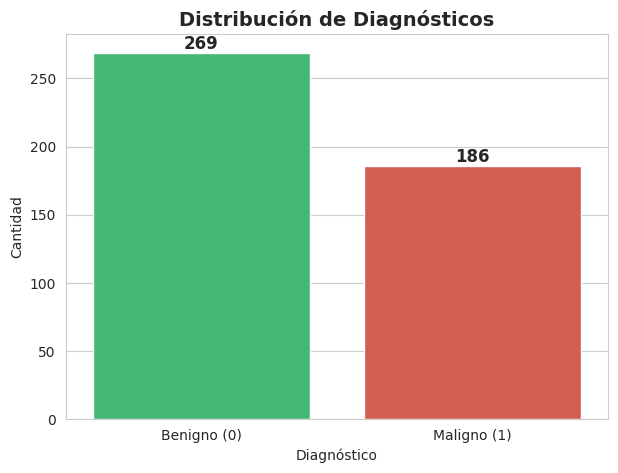


Porcentaje de malignos: 40.9%


In [9]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_train, x='diagnosis', palette=['#2ecc71', '#e74c3c'])
plt.xticks([0, 1], ['Benigno (0)', 'Maligno (1)'])
plt.title('Distribución de Diagnósticos', fontsize=14, fontweight='bold')
plt.xlabel('Diagnóstico')
plt.ylabel('Cantidad')

# Agregar conteo sobre las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
               ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

print(f'\nPorcentaje de malignos: {df_train["diagnosis"].mean()*100:.1f}%')

Se observa un ligero desbalance en los datos, con mayor cantidad de casos benignos que malignos. Esto es importante tenerlo en cuenta para futuros modelos de predicción, ya que un modelo podría sesgarse hacia la clase mayoritaria.

### 2. Distribución de variables principales (Histogramas)

Se seleccionan las variables de media (`radius1`, `texture1`, `perimeter1`, `area1`, `smoothness1`, `compactness1`) por ser las mediciones directas más representativas de las características del tumor.

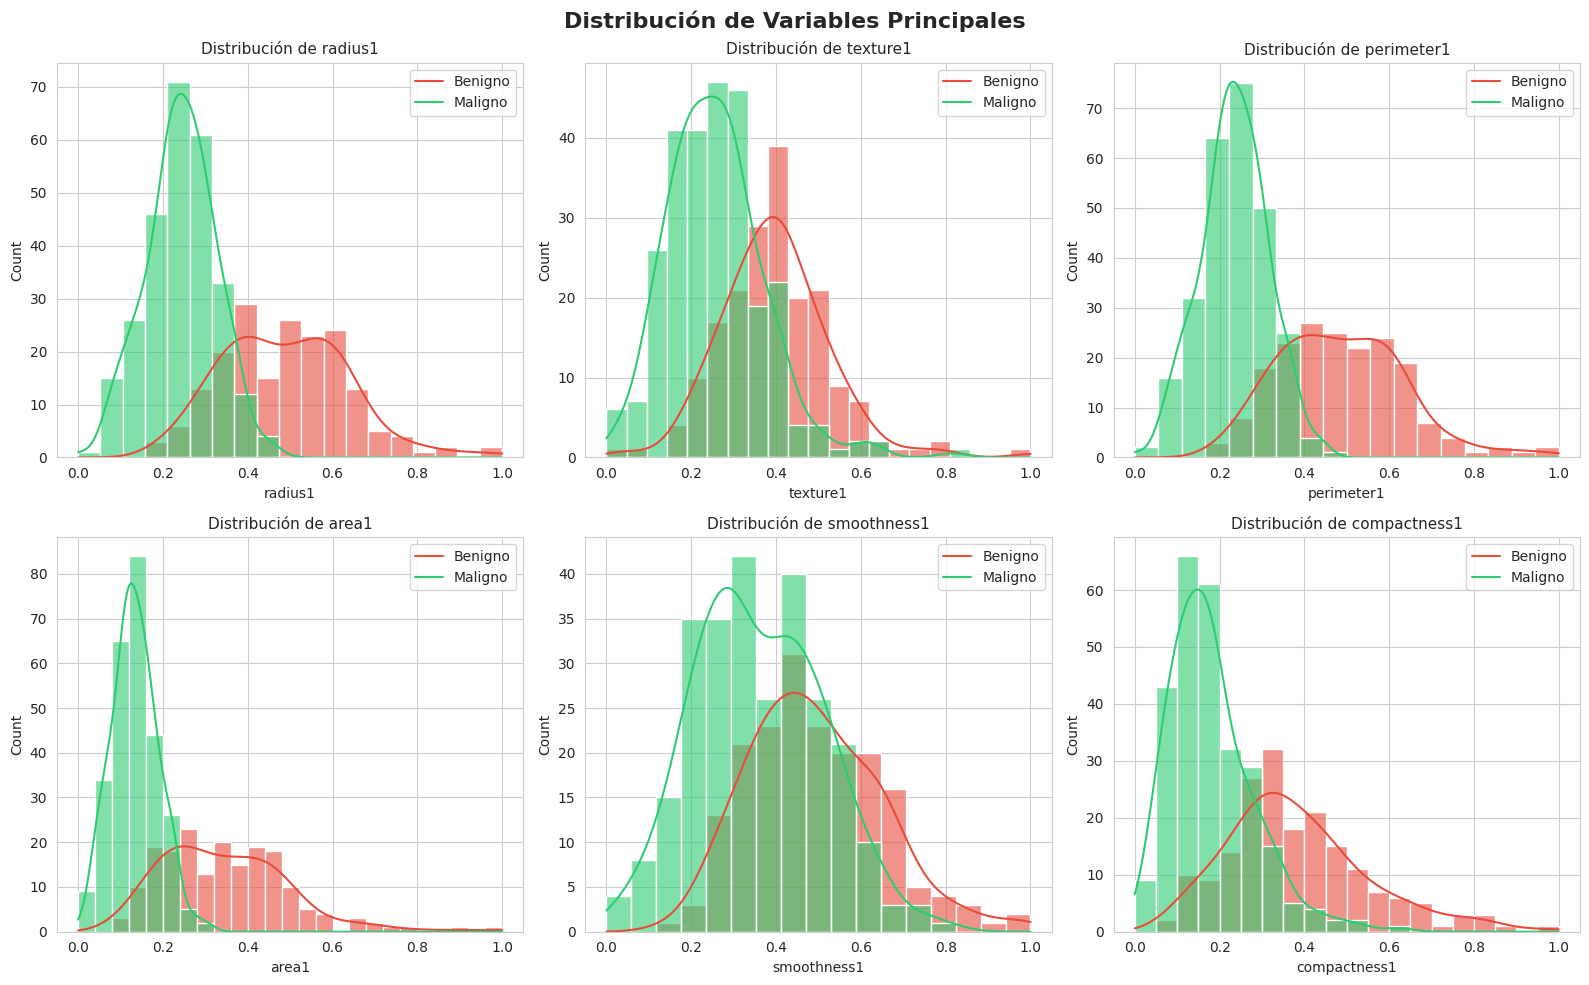

In [10]:
variables_principales = ['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribución de Variables Principales', fontsize=16, fontweight='bold')

for i, var in enumerate(variables_principales):
    ax = axes[i // 3, i % 3]
    sns.histplot(data=df_train, x=var, hue='diagnosis', kde=True, ax=ax,
                 palette=['#2ecc71', '#e74c3c'], alpha=0.6)
    ax.set_title(f'Distribución de {var}', fontsize=11)
    ax.legend(['Benigno', 'Maligno'])

plt.tight_layout()
plt.show()

Las variables `radius1`, `perimeter1` y `area1` muestran una clara separación entre tumores benignos y malignos: los tumores malignos tienden a tener valores más altos. Esto indica que el tamaño del tumor es un factor determinante para la clasificación. Variables como `texture1` y `smoothness1` muestran mayor solapamiento entre ambas clases, lo que sugiere menor poder discriminativo por sí solas.

### 3. Boxplots por diagnóstico

Los boxplots permiten comparar la distribución de cada variable entre tumores benignos y malignos, e identificar outliers.

/tmp/ipykernel_3028/35076455.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='diagnosis', y=var, ax=ax,
/tmp/ipykernel_3028/35076455.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Benigno', 'Maligno'])
/tmp/ipykernel_3028/35076455.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='diagnosis', y=var, ax=ax,
/tmp/ipykernel_3028/35076455.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Benigno', 'Maligno'])
/tmp/ipykernel_3028/35076455.py:

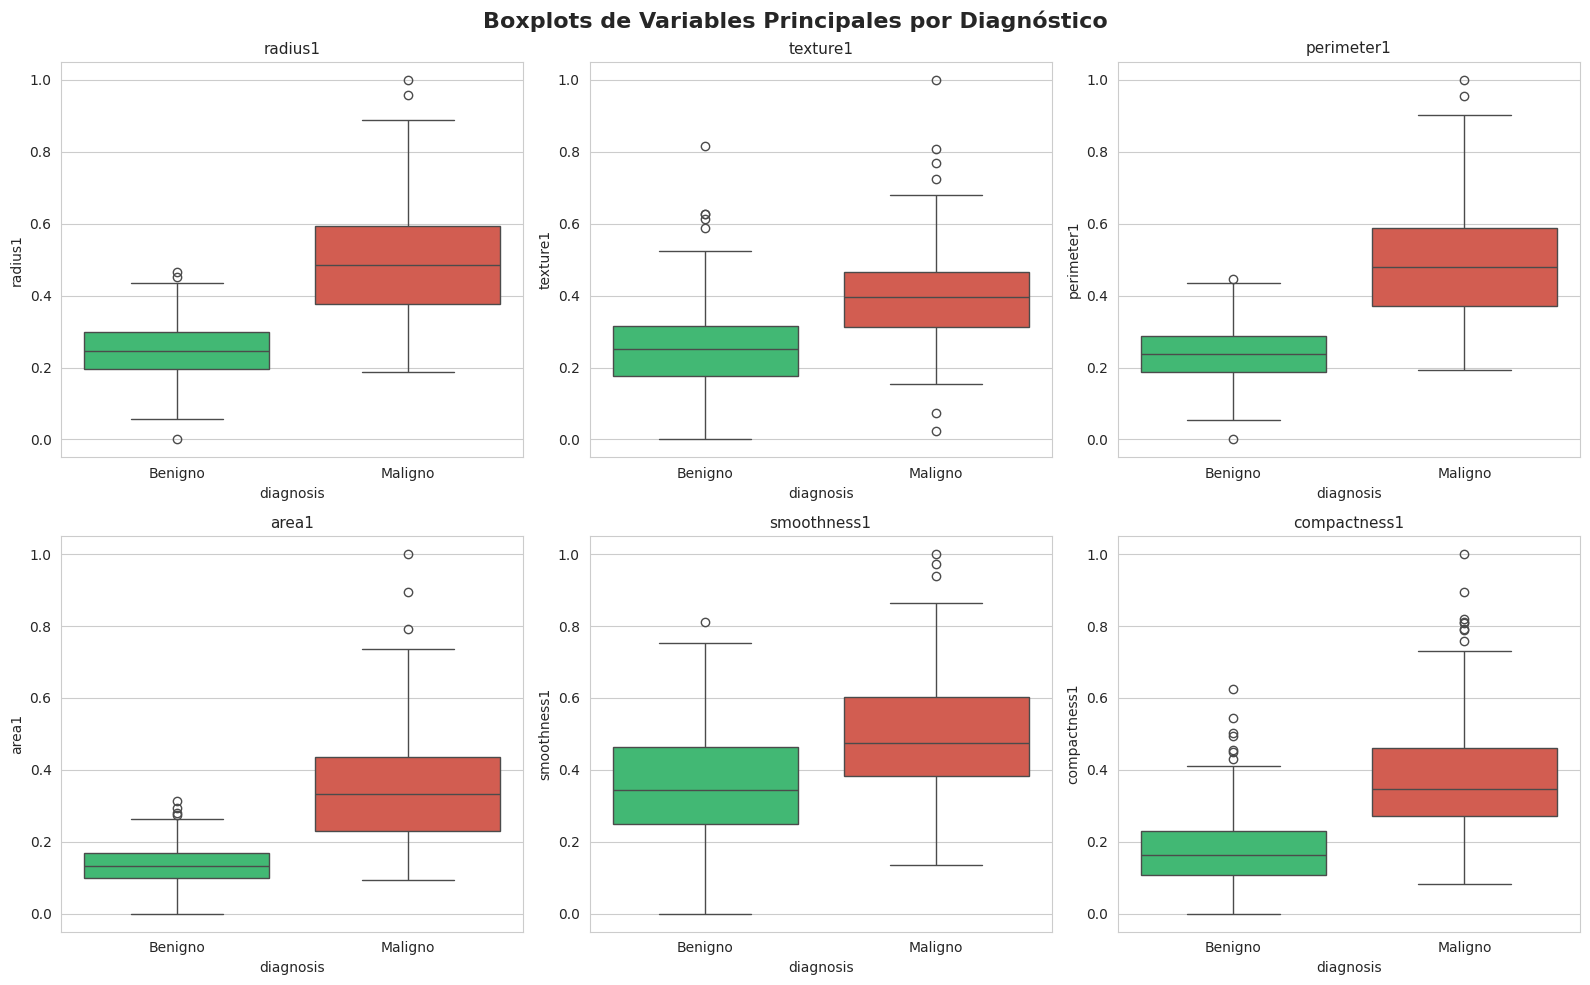

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Boxplots de Variables Principales por Diagnóstico', fontsize=16, fontweight='bold')

for i, var in enumerate(variables_principales):
    ax = axes[i // 3, i % 3]
    sns.boxplot(data=df_train, x='diagnosis', y=var, ax=ax,
                palette=['#2ecc71', '#e74c3c'])
    ax.set_xticklabels(['Benigno', 'Maligno'])
    ax.set_title(f'{var}', fontsize=11)

plt.tight_layout()
plt.show()

Los boxplots confirman lo observado en los histogramas. Las variables `radius1`, `perimeter1` y `area1` presentan medianas notablemente distintas entre ambos grupos, lo que refuerza su utilidad para la predicción. Se detectan algunos outliers, especialmente en `area1` para tumores malignos, que podrían corresponder a tumores de gran tamaño.

### 4. Matriz de correlación

La matriz de correlación nos ayuda a identificar las relaciones lineales entre variables y detectar posibles redundancias (multicolinealidad).

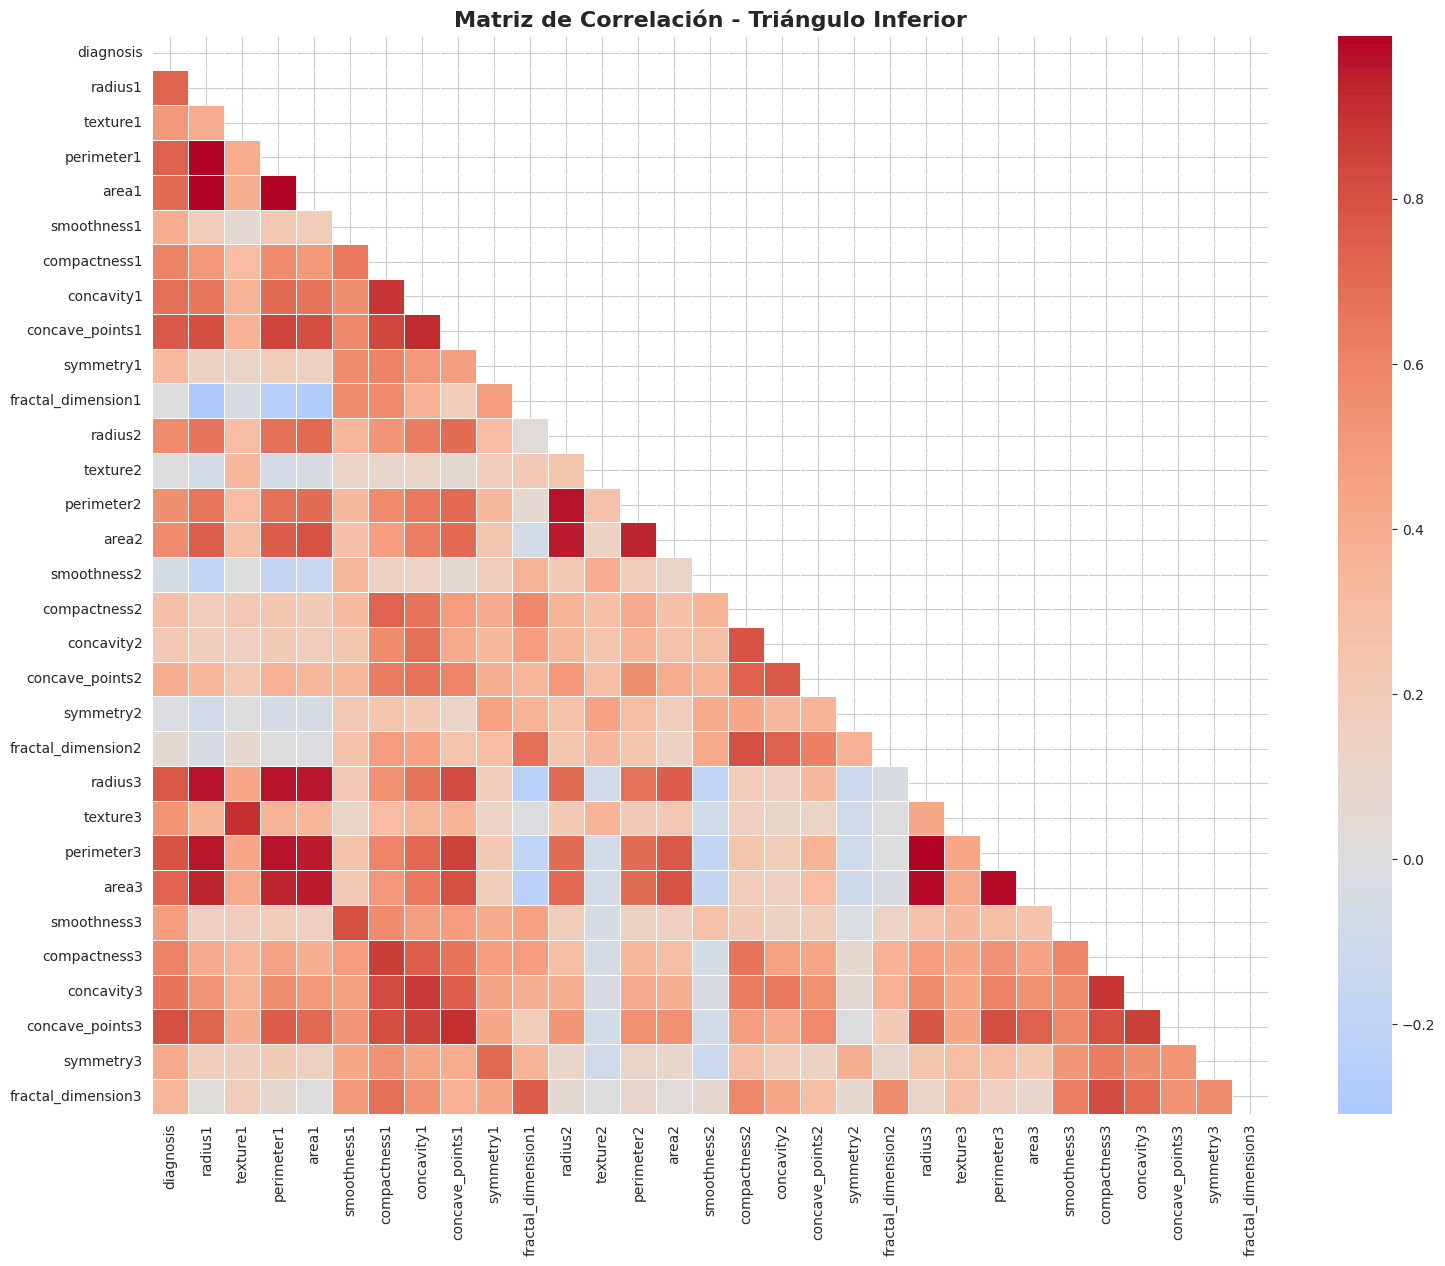

In [12]:
# Matriz de correlación completa
# Matriz de correlación - triángulo inferior
correlacion = df_train.corr()

# Crear máscara para ocultar el triángulo superior
mascara = np.triu(np.ones_like(correlacion, dtype=bool))

plt.figure(figsize=(18, 14))
sns.heatmap(correlacion, mask=mascara, cmap='coolwarm', center=0,
            annot=False, linewidths=0.5)
plt.title('Matriz de Correlación - Triángulo Inferior', fontsize=16, fontweight='bold')
plt.show()

**Interpretación:** Se observa una alta correlación entre variables relacionadas con el tamaño del tumor (radius, perimeter, area), lo cual es esperado ya que son medidas geométricamente dependientes. Esta multicolinealidad sugiere que en un modelo predictivo no sería necesario incluir todas estas variables, ya que aportan información redundante.

### 5. Variables más correlacionadas con el diagnóstico

Top 10 variables más correlacionadas con el diagnóstico:
concave_points3    0.800212
perimeter3         0.784807
radius3            0.777265
concave_points1    0.770923
perimeter1         0.740257
area3              0.734534
radius1            0.727111
area1              0.704369
concavity1         0.680258
concavity3         0.661189
Name: diagnosis, dtype: float64


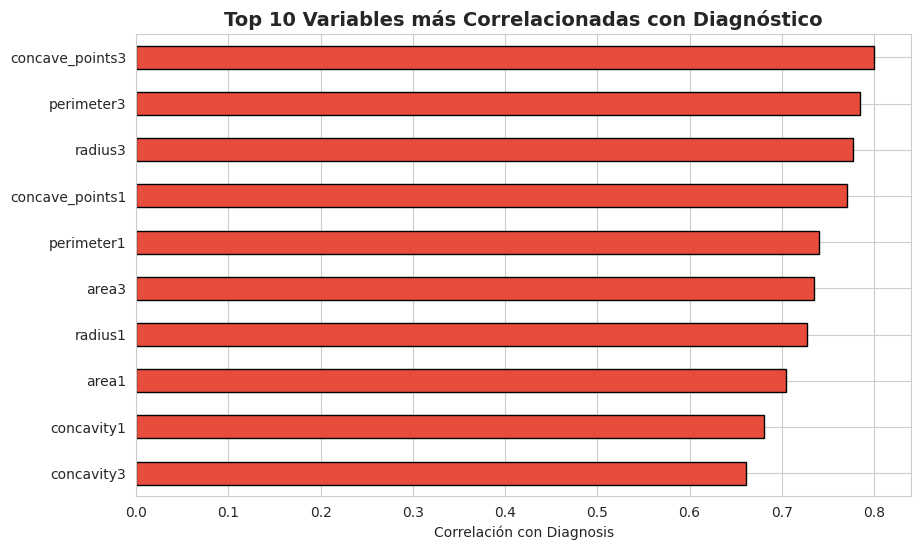

In [13]:
# Top 10 variables más correlacionadas con diagnosis
corr_diagnosis = correlacion['diagnosis'].drop('diagnosis').sort_values(ascending=False)

print('Top 10 variables más correlacionadas con el diagnóstico:')
print(corr_diagnosis.head(10))

plt.figure(figsize=(10, 6))
corr_diagnosis.head(10).plot(kind='barh', color='#e74c3c', edgecolor='black')
plt.title('Top 10 Variables más Correlacionadas con Diagnóstico', fontsize=14, fontweight='bold')
plt.xlabel('Correlación con Diagnosis')
plt.gca().invert_yaxis()
plt.show()

Las variables con mayor correlación positiva con el diagnóstico maligno son las relacionadas con el tamaño y la concavidad del tumor. Esto indica que tumores más grandes y con bordes más irregulares tienen mayor probabilidad de ser malignos. Estas variables serían las más relevantes como predictoras en un modelo de clasificación.

### 6. Pairplot de variables más relevantes

El pairplot permite visualizar simultáneamente las relaciones entre pares de variables y su distribución, coloreadas por diagnóstico.

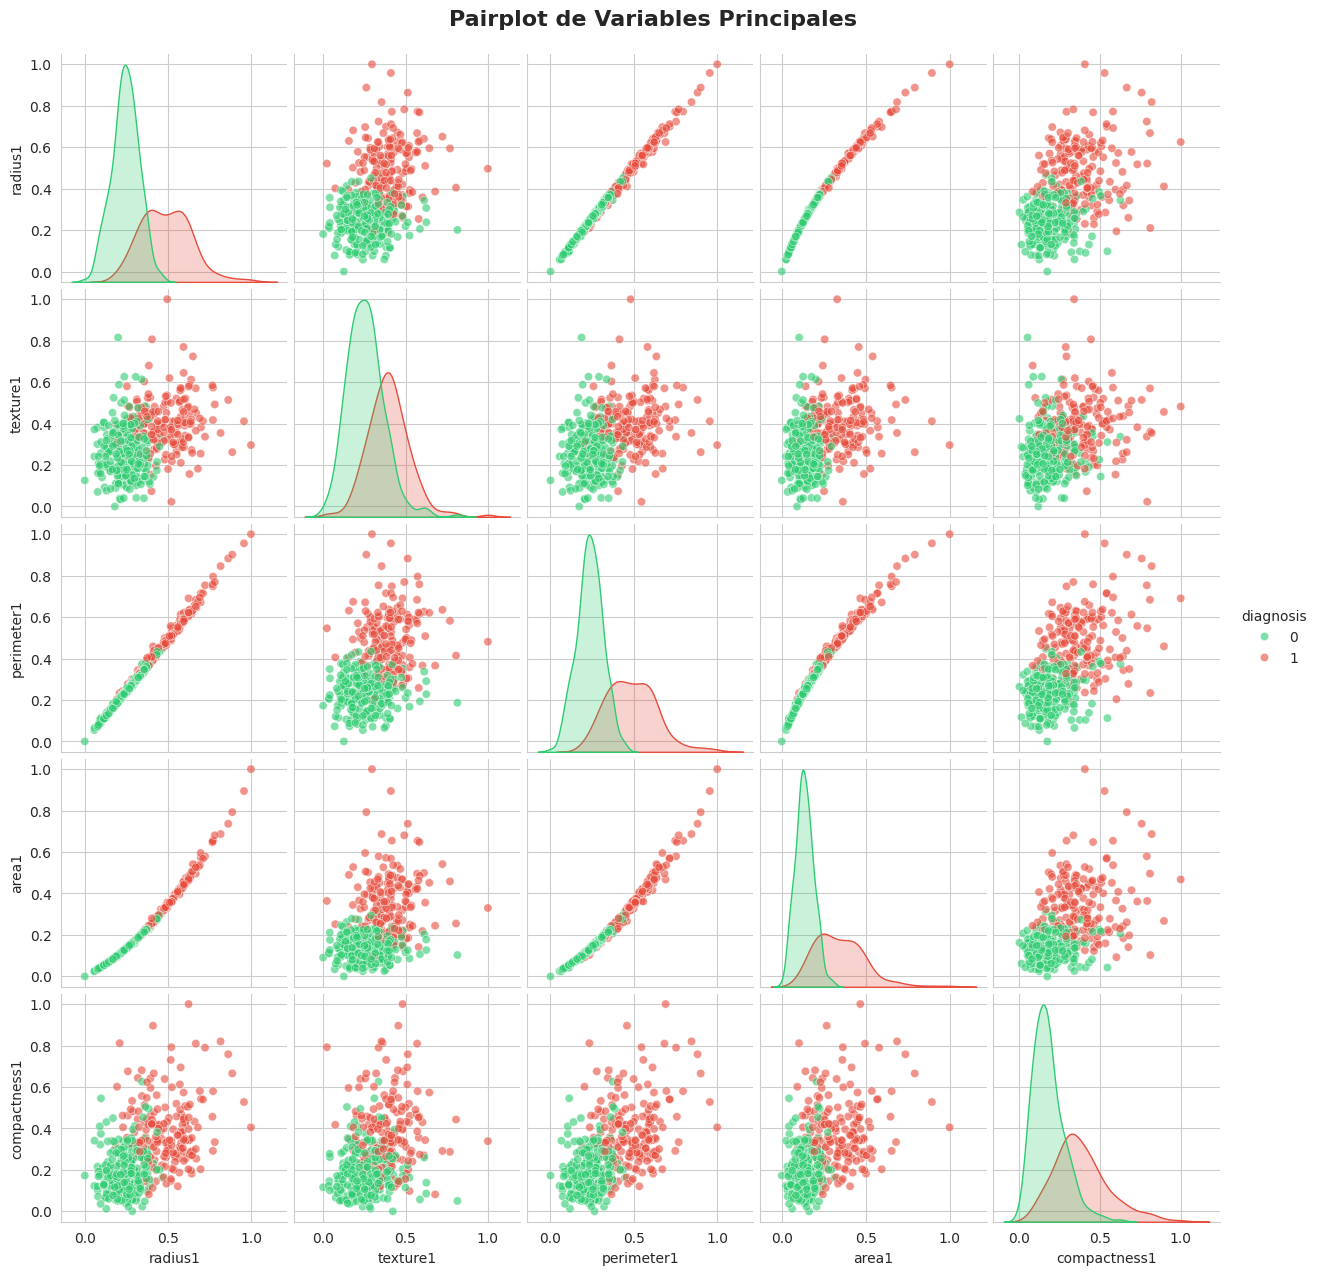

In [14]:
variables_pairplot = ['diagnosis', 'radius1', 'texture1', 'perimeter1', 'area1', 'compactness1']

sns.pairplot(df_train[variables_pairplot], hue='diagnosis',
             palette=['#2ecc71', '#e74c3c'],
             diag_kind='kde',
             plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot de Variables Principales', y=1.02, fontsize=16, fontweight='bold')
plt.show()

El pairplot confirma que las combinaciones de variables como `radius1` vs `perimeter1` y `radius1` vs `area1` permiten una separación visual clara entre tumores benignos y malignos. Esto sugiere que un modelo de clasificación podría lograr un buen desempeño utilizando estas características como predictores principales.

---
### Conclusiones Generales Semana1

1. El dataset no presenta valores perdidos, lo cual facilita el análisis sin necesidad de imputación.
2. Existe un ligero desbalance entre las clases benigno y maligno, que debe considerarse al entrenar modelos predictivos.
3. Las variables más relevantes para la predicción son las relacionadas con el tamaño del tumor (radius, perimeter, area) y la concavidad de sus bordes.
4. Se detectó alta multicolinealidad entre variables de tamaño, lo que sugiere que podría aplicarse reducción de dimensionalidad o selección de características.
5. La normalización de los datos se realizó con MinMaxScaler, ajustando los valores al rango [0, 1], lo cual es importante para algoritmos sensibles a la escala de las variables.
6. El desarrollo de la práctica permitió aplicar correctamente las etapas de preprocesamiento y análisis exploratorio de datos utilizando Python y sus librerías especializadas. A través de las estadísticas descriptivas y visualizaciones se logró comprender mejor el comportamiento del dataset y la relación entre las variables analizadas.
7. El análisis realizado permitió identificar variables relevantes asociadas al diagnóstico, además de evidenciar la importancia de la limpieza, transformación y exploración de datos como parte fundamental de cualquier proyecto.


---
### Aplicación en campo profesional Semana 1

1. **Santiago Calle:** En esta semana, lo que aprendí puede aplicarse en el entorno industrial y de automatización para analizar datos de sensores, detectar fallas y optimizar procesos de trabajo. Así como el modelo clasifica datos médicos para identificar si un tumor es benigno o maligno, en el área industrial puede utilizarse para clasificar el estado de máquinas y equipos como “funcionamiento normal” o “posible falla”, utilizando variables como temperatura, corriente, presión, vibración o tiempo de operación. En equipos como selladoras, bombas, motores o sistemas automáticos, este tipo de análisis permitiría detectar anomalías, predecir mantenimientos y mejorar la calidad del proceso antes de que ocurra una falla grave. Las técnicas utilizadas como el análisis de correlaciones, normalización de datos y evaluación de precisión, ayudan a comprender mejor el comportamiento de los sistemas industriales y facilitan la toma de decisiones técnicas.

2. **Alexander Luna:** En el Registro de la Propiedad podemos entrenar un modelo predictivo con el histórico de transacciones para clasificar y predecir el riesgo o la viabilidad de las solicitudes de inscripción. Evaluando variables como el tipo de propiedad, la cuantía de la tasa, el perfil del solicitante o el historial del predio, optimizaríamos el Recall para asegurar que el sistema detecte y alerte sobre cualquier posible inconsistencia o anomalía jurídica de alto impacto antes de que la documentación pase a la firma del Registrador o Jerárquico Superior.

3. **Alvaro Quisilema:** Como ingeniero mecatrónico especializado en sistemas de seguridad y control de asistencia, este tipo de análisis de datos es directamente aplicable a mi campo profesional. Por ejemplo, puedo utilizar la misma metodología para analizar datos de sensores en dispositivos de control de acceso ( biométricos, torniquetes, cámaras) y predecir fallos antes de que ocurran, identificando qué variables como temperatura, tiempo de respuesta o voltaje son las más relevantes. De igual forma, en el área de control de asistencia, este enfoque me permite detectar patrones de ausentismo o anomalías en los registros de marcación, facilitando una gestión más eficiente y basada en datos.


---
## SEMANA 2 - Predicción con Modelos de Clasificación

### 1. Regresión Logística

#### 1.1 Modelo Baseline (versión inicial)

Se implementa el modelo de Regresión Logística con los parámetros por defecto de Scikit-Learn para establecer una línea base de rendimiento.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

# Separar variables predictoras (X) y variable objetivo (y)
# Para entrenar utilizamos todas las variables menos diagnostico
X_train = df_train.drop('diagnosis', axis=1)
y_train = df_train['diagnosis']

X_test = df_test.drop('diagnosis', axis=1)
y_test = df_test['diagnosis']

print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (455, 30)
y_train: (455,)
X_test: (114, 30)
y_test: (114,)


#### 1.2 Entrenamiento y evaluación del modelo baseline

In [16]:
# Crear el modelo de Regresión Logística con parámetros por defecto
modelo_lr_base = LogisticRegression(max_iter=10000, random_state=42)

# Entrenar el modelo con los datos de entrenamiento
modelo_lr_base.fit(X_train, y_train)

# Predecir con los datos de prueba
y_pred_lr_base = modelo_lr_base.predict(X_test)

# Métricas de evaluación
print('=== REGRESIÓN LOGÍSTICA===\n')
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred_lr_base, target_names=['Benigno', 'Maligno']))

print(f'Accuracy:  {accuracy_score(y_test, y_pred_lr_base):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr_base):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_lr_base):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_lr_base):.4f}')

=== REGRESIÓN LOGÍSTICA===

Reporte de clasificación:
              precision    recall  f1-score   support

     Benigno       0.98      0.99      0.98        88
     Maligno       0.96      0.92      0.94        26

    accuracy                           0.97       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.97      0.97       114

Accuracy:  0.9737
Precision: 0.9600
Recall:    0.9231
F1-Score:  0.9412


#### 1.3 Gráficas de evaluación - Baseline

<Figure size 700x500 with 0 Axes>

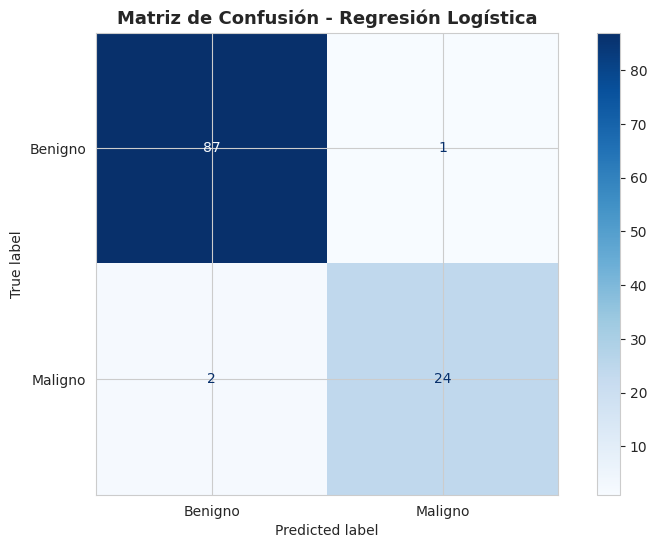

In [17]:
# --- Matriz de Confusión ---
plt.figure(figsize=(7, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr_base,
                                         display_labels=['Benigno', 'Maligno'],
                                         cmap='Blues')
plt.title('Matriz de Confusión - Regresión Logística', fontsize=13, fontweight='bold')
plt.show()



#### 1.4 Modelo Mejorado - Regresión Logística

Se mejora el modelo seleccionando únicamente las variables más correlacionadas con el diagnóstico (identificadas en el análisis exploratorio) y ajustando el hiperparámetro C (fuerza de regularización).

In [18]:
# Seleccionar las 10 variables más correlacionadas con diagnosis
corr_con_diagnosis = df_train.drop('diagnosis', axis=1).corrwith(df_train['diagnosis']).abs()
top_variables = corr_con_diagnosis.sort_values(ascending=False).head(10).index.tolist()

print('Variables seleccionadas:')
for i, var in enumerate(top_variables, 1):
    print(f'  {i}. {var} (corr: {corr_con_diagnosis[var]:.4f})')

# Crear datasets con solo las variables seleccionadas
X_train_top = X_train[top_variables]
X_test_top = X_test[top_variables]

# Modelo mejorado con hiperparámetro C ajustado
modelo_lr_mejorado = LogisticRegression(C=0.5, max_iter=10000, random_state=42)
modelo_lr_mejorado.fit(X_train_top, y_train)

# Predecir
y_pred_lr_mejor = modelo_lr_mejorado.predict(X_test_top)

# Métricas
print('\n=== REGRESIÓN LOGÍSTICA - MEJORADO ===\n')
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred_lr_mejor, target_names=['Benigno', 'Maligno']))

print(f'Accuracy:  {accuracy_score(y_test, y_pred_lr_mejor):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr_mejor):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_lr_mejor):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_lr_mejor):.4f}')

Variables seleccionadas:
  1. concave_points3 (corr: 0.8002)
  2. perimeter3 (corr: 0.7848)
  3. radius3 (corr: 0.7773)
  4. concave_points1 (corr: 0.7709)
  5. perimeter1 (corr: 0.7403)
  6. area3 (corr: 0.7345)
  7. radius1 (corr: 0.7271)
  8. area1 (corr: 0.7044)
  9. concavity1 (corr: 0.6803)
  10. concavity3 (corr: 0.6612)

=== REGRESIÓN LOGÍSTICA - MEJORADO ===

Reporte de clasificación:
              precision    recall  f1-score   support

     Benigno       0.98      0.98      0.98        88
     Maligno       0.92      0.92      0.92        26

    accuracy                           0.96       114
   macro avg       0.95      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Accuracy:  0.9649
Precision: 0.9231
Recall:    0.9231
F1-Score:  0.9231


<Figure size 700x500 with 0 Axes>

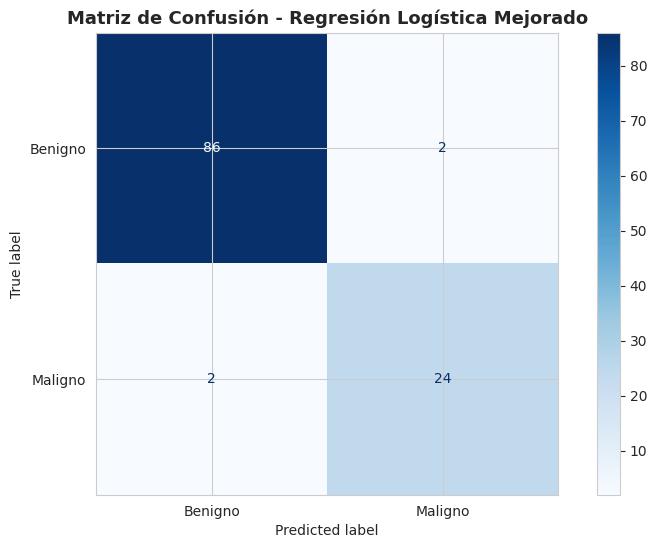

In [19]:
# --- Matriz de Confusión - Mejorado ---
plt.figure(figsize=(7, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr_mejor,
                                         display_labels=['Benigno', 'Maligno'],
                                         cmap='Blues')
plt.title('Matriz de Confusión - Regresión Logística Mejorado', fontsize=13, fontweight='bold')
plt.show()

#### 1.5 Interpretación - Regresión Logística

**Baseline:** El modelo con las 30 variables y parámetros por defecto (C=1.0) obtuvo un accuracy del 97.37%, con un recall del 92.31% para la clase maligna, lo que significa que detectó correctamente 24 de los 26 casos malignos.

**Mejorado:** Al reducir a las 10 variables más correlacionadas y ajustar C=0.5, el accuracy bajó ligeramente a 96.49%. El recall se mantuvo en 92.31%, pero la precision disminuyó de 96% a 92.31%.

**Conclusión:** El modelo baseline resultó más efectivo en este caso. Esto sugiere que variables con menor correlación individual pueden aportar información complementaria cuando se combinan con otras, y que la regularización más fuerte (C=0.5) no mejoró el rendimiento. No obstante, el modelo mejorado tiene la ventaja de usar menos variables (10 vs 30), lo que lo hace más simple e interpretable.

---
### 2. K-Nearest Neighbors (K-NN)

#### 2.1 Modelo Baseline

Se implementa K-NN con el parámetro por defecto de Scikit-Learn (K=5, es decir, analiza los 5 vecinos más cercanos).

=== K-NN - BASELINE (K=5) ===

Reporte de clasificación:
              precision    recall  f1-score   support

     Benigno       1.00      0.95      0.98        88
     Maligno       0.87      1.00      0.93        26

    accuracy                           0.96       114
   macro avg       0.93      0.98      0.95       114
weighted avg       0.97      0.96      0.97       114

Accuracy:  0.9649
Precision: 0.8667
Recall:    1.0000
F1-Score:  0.9286


<Figure size 700x500 with 0 Axes>

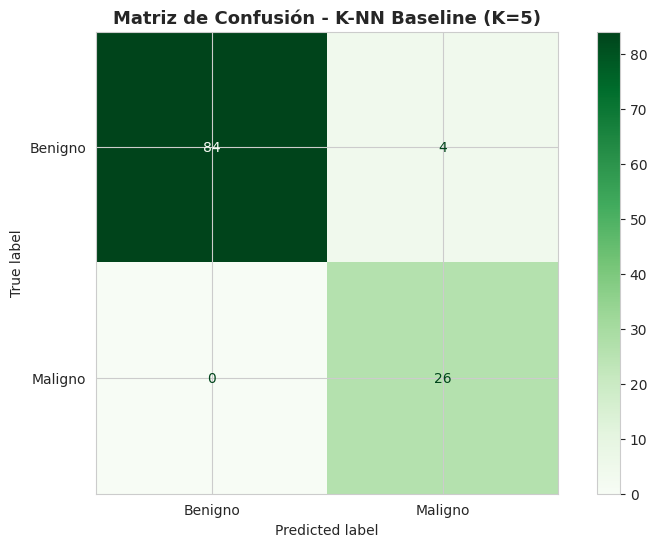

In [20]:
from sklearn.neighbors import KNeighborsClassifier

# Crear modelo K-NN con parámetros por defecto (k=5)
modelo_knn_base = KNeighborsClassifier()

# Entrenar
modelo_knn_base.fit(X_train, y_train)

# Predecir
y_pred_knn_base = modelo_knn_base.predict(X_test)

# Métricas
print('=== K-NN - BASELINE (K=5) ===\n')
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred_knn_base, target_names=['Benigno', 'Maligno']))

print(f'Accuracy:  {accuracy_score(y_test, y_pred_knn_base):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_knn_base):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_knn_base):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_knn_base):.4f}')

# Matriz de confusión
plt.figure(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn_base,
                                         display_labels=['Benigno', 'Maligno'],
                                         cmap='Greens')
plt.title('Matriz de Confusión - K-NN Baseline (K=5)', fontsize=13, fontweight='bold')
plt.show()

#### 2.2 Modelo Mejorado - K-NN

Se busca el valor óptimo de K probando diferentes valores y evaluando el accuracy de cada uno.

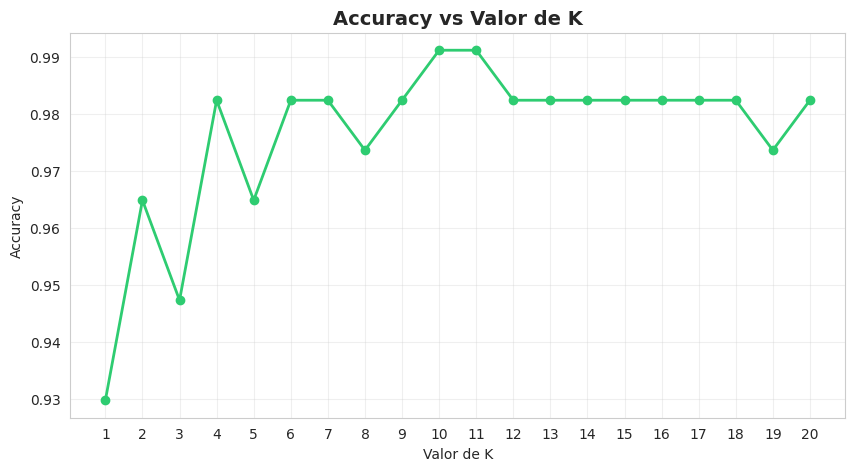

Mejor K: 10 con accuracy: 0.9912


In [21]:
# Probar diferentes valores de K
k_valores = range(1, 21)
accuracies = []

for k in k_valores:
    modelo_temp = KNeighborsClassifier(n_neighbors=k)
    modelo_temp.fit(X_train, y_train)
    acc = accuracy_score(y_test, modelo_temp.predict(X_test))
    accuracies.append(acc)

# Gráfica de K vs Accuracy
plt.figure(figsize=(10, 5))
plt.plot(k_valores, accuracies, marker='o', color='#2ecc71', linewidth=2)
plt.xlabel('Valor de K')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Valor de K', fontsize=14, fontweight='bold')
plt.xticks(k_valores)
plt.grid(True, alpha=0.3)
plt.show()

# Mejor K
mejor_k = list(k_valores)[np.argmax(accuracies)]
print(f'Mejor K: {mejor_k} con accuracy: {max(accuracies):.4f}')

=== K-NN - MEJORADO (K=10) ===

Reporte de clasificación:
              precision    recall  f1-score   support

     Benigno       1.00      0.99      0.99        88
     Maligno       0.96      1.00      0.98        26

    accuracy                           0.99       114
   macro avg       0.98      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114

Accuracy:  0.9912
Precision: 0.9630
Recall:    1.0000
F1-Score:  0.9811


<Figure size 700x500 with 0 Axes>

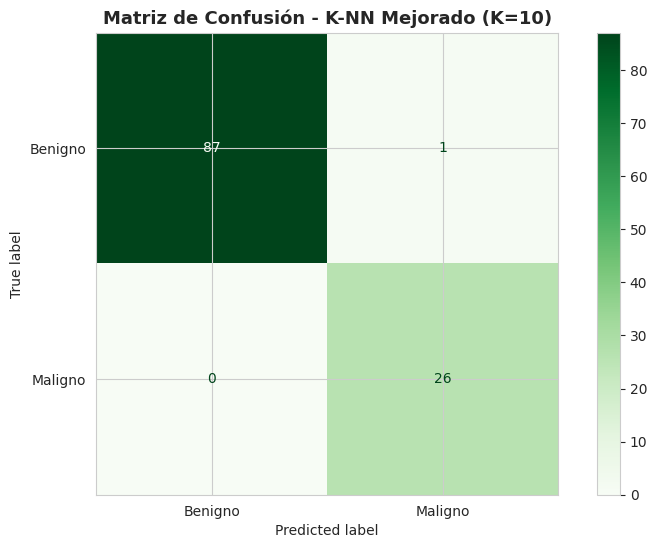

In [22]:
# Modelo mejorado con K=10
modelo_knn_mejor = KNeighborsClassifier(n_neighbors=10)
modelo_knn_mejor.fit(X_train, y_train)

# Predecir
y_pred_knn_mejor = modelo_knn_mejor.predict(X_test)

# Métricas
print('=== K-NN - MEJORADO (K=10) ===\n')
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred_knn_mejor, target_names=['Benigno', 'Maligno']))

print(f'Accuracy:  {accuracy_score(y_test, y_pred_knn_mejor):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_knn_mejor):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_knn_mejor):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_knn_mejor):.4f}')

# Matriz de confusión
plt.figure(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn_mejor,
                                         display_labels=['Benigno', 'Maligno'],
                                         cmap='Greens')
plt.title('Matriz de Confusión - K-NN Mejorado (K=10)', fontsize=13, fontweight='bold')
plt.show()

#### 2.3 Interpretación - K-NN

**Baseline (K=5):** El modelo alcanzó un accuracy del 96.49% con un recall perfecto del 100% para la clase maligna, lo que significa que detectó todos los casos malignos. Sin embargo, la precision fue de 86.67%, lo que indica que algunos casos benignos fueron clasificados erróneamente como malignos.

**Mejorado (K=10):** Al ajustar el número de vecinos a K=10, el accuracy subió al 99.12%, la precision mejoró significativamente de 86.67% a 96.30% y el recall se mantuvo en 100%. Esto convierte al K-NN mejorado en el mejor modelo de todos los evaluados.

---
### 3. Comparación de Modelos

In [23]:
# Tabla comparativa
resultados = pd.DataFrame({
    'Modelo': ['LR Baseline', 'LR Mejorado', 'KNN Baseline (K=5)', 'KNN Mejorado (K=10)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr_base),
        accuracy_score(y_test, y_pred_lr_mejor),
        accuracy_score(y_test, y_pred_knn_base),
        accuracy_score(y_test, y_pred_knn_mejor)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr_base),
        precision_score(y_test, y_pred_lr_mejor),
        precision_score(y_test, y_pred_knn_base),
        precision_score(y_test, y_pred_knn_mejor)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr_base),
        recall_score(y_test, y_pred_lr_mejor),
        recall_score(y_test, y_pred_knn_base),
        recall_score(y_test, y_pred_knn_mejor)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr_base),
        f1_score(y_test, y_pred_lr_mejor),
        f1_score(y_test, y_pred_knn_base),
        f1_score(y_test, y_pred_knn_mejor)
    ]
})

resultados = resultados.round(4)
print('=== COMPARACIÓN DE MODELOS ===\n')
print(resultados.to_string(index=False))

=== COMPARACIÓN DE MODELOS ===

             Modelo  Accuracy  Precision  Recall  F1-Score
        LR Baseline    0.9737     0.9600  0.9231    0.9412
        LR Mejorado    0.9649     0.9231  0.9231    0.9231
 KNN Baseline (K=5)    0.9649     0.8667  1.0000    0.9286
KNN Mejorado (K=10)    0.9912     0.9630  1.0000    0.9811


---
### 4. Conclusiones Generales Semana 2

1. **Mejor modelo:** K-NN con K=10 obtuvo el mejor rendimiento general con un accuracy del 99.12% y un recall perfecto del 100%, lo que significa que detectó todos los casos de cáncer maligno sin excepción.

2. **Regresión Logística** tuvo un buen desempeño con un accuracy del 97.37% en su versión baseline, pero no logró detectar 2 de los 26 casos malignos (recall de 92.31%). La versión mejorada con selección de variables y ajuste de C no superó al baseline, lo que sugiere que las 30 variables originales aportan información complementaria al modelo.

3. **K-NN** demostró ser más sensible para detectar todos los casos malignos (recall del 100% en ambas versiones). Al ajustar el hiperparámetro K de 5 a 10, la precision mejoró significativamente de 86.67% a 96.30%, reduciendo los falsos positivos.

4. **En un contexto médico**, el recall es la métrica más crítica porque un falso negativo (no detectar un tumor maligno) puede tener consecuencias graves para la paciente. Por esta razón, K-NN con K=10 es el modelo más adecuado para este problema, ya que combina un recall perfecto con alta precision.

5. **El preprocesamiento y análisis exploratorio** fueron fundamentales para comprender los datos. La normalización con MinMaxScaler fue especialmente importante para K-NN, ya que este algoritmo se basa en distancias y es sensible a la escala de las variables.

---
### Aplicación en campo profesional Semana 2

1. **Santiago Calle:** Como ingeniero mecatrónico, los algoritmos de clasificación como Regresión Logística y K-NN son aplicables al mantenimiento preventivo industrial. A partir de datos generados por sensores en máquinas y procesos automatizados como temperatura, corriente, presión y tiempos de operación, es posible entrenar modelos que clasifiquen el estado de los equipos como 'funcionamiento normal' o 'fallo inminente'. El análisis exploratorio y preprocesamiento de datos permite identificar tendencias y comportamientos anormales, obteniendo información más confiable para la toma de decisiones y mejorando la eficiencia de los sistemas industriales.

2. **Alexander Luna:** En el Registro de la Propiedad podemos entrenar un modelo predictivo con el histórico de transacciones para clasificar y predecir el riesgo o la viabilidad de las solicitudes de inscripción. Evaluando variables como el tipo de propiedad, la cuantía de la tasa, el perfil del solicitante o el historial del predio, optimizaríamos el Recall para asegurar que el sistema detecte y alerte sobre cualquier posible inconsistencia o anomalía jurídica de alto impacto antes de que la documentación pase a la firma del Registrador o Jerárquico Superior.

3. **Alvaro Quisilema:** Como ingeniero mecatrónico especializado en sistemas de seguridad y control de asistencia, este tipo de análisis de datos es directamente aplicable a mi campo profesional. Por ejemplo, puedo utilizar la misma metodología para analizar datos de sensores en dispositivos de control de acceso ( biométricos, torniquetes, cámaras) y predecir fallos antes de que ocurran, identificando qué variables como temperatura, tiempo de respuesta o voltaje son las más relevantes. De igual forma, en el área de control de asistencia, este enfoque me permite detectar patrones de ausentismo o anomalías en los registros de marcación, facilitando una gestión más eficiente y basada en datos.

---
## SEMANA 3 - Árbol de Decisión, Bosque Aleatorio y Red Neuronal



### 1. Árbol de Decisión



#### 1.1 Modelo Baseline
Se implementa el Árbol de Decisión con parámetros por defecto de Scikit-Learn.

=== ÁRBOL DE DECISIÓN - BASELINE ===

Reporte de clasificación:
              precision    recall  f1-score   support

     Benigno       0.96      0.84      0.90        88
     Maligno       0.62      0.88      0.73        26

    accuracy                           0.85       114
   macro avg       0.79      0.86      0.81       114
weighted avg       0.88      0.85      0.86       114

Accuracy:  0.8509
Precision: 0.6216
Recall:    0.8846
F1-Score:  0.7302


<Figure size 700x500 with 0 Axes>

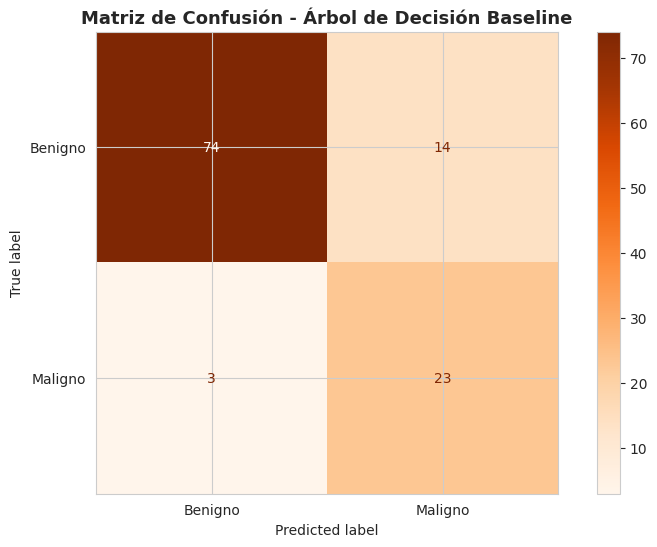

In [24]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Crear modelo con parámetros por defecto
modelo_arbol_base = DecisionTreeClassifier(random_state=42)

# Entrenar
modelo_arbol_base.fit(X_train, y_train)

# Predecir
y_pred_arbol_base = modelo_arbol_base.predict(X_test)

# Métricas
print('=== ÁRBOL DE DECISIÓN - BASELINE ===\n')
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred_arbol_base, target_names=['Benigno', 'Maligno']))

print(f'Accuracy:  {accuracy_score(y_test, y_pred_arbol_base):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_arbol_base):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_arbol_base):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_arbol_base):.4f}')

# Matriz de confusión
plt.figure(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_arbol_base,
                                         display_labels=['Benigno', 'Maligno'],
                                         cmap='Oranges')
plt.title('Matriz de Confusión - Árbol de Decisión Baseline', fontsize=13, fontweight='bold')
plt.show()

#### 1.2 Visualización del Árbol de Decisión

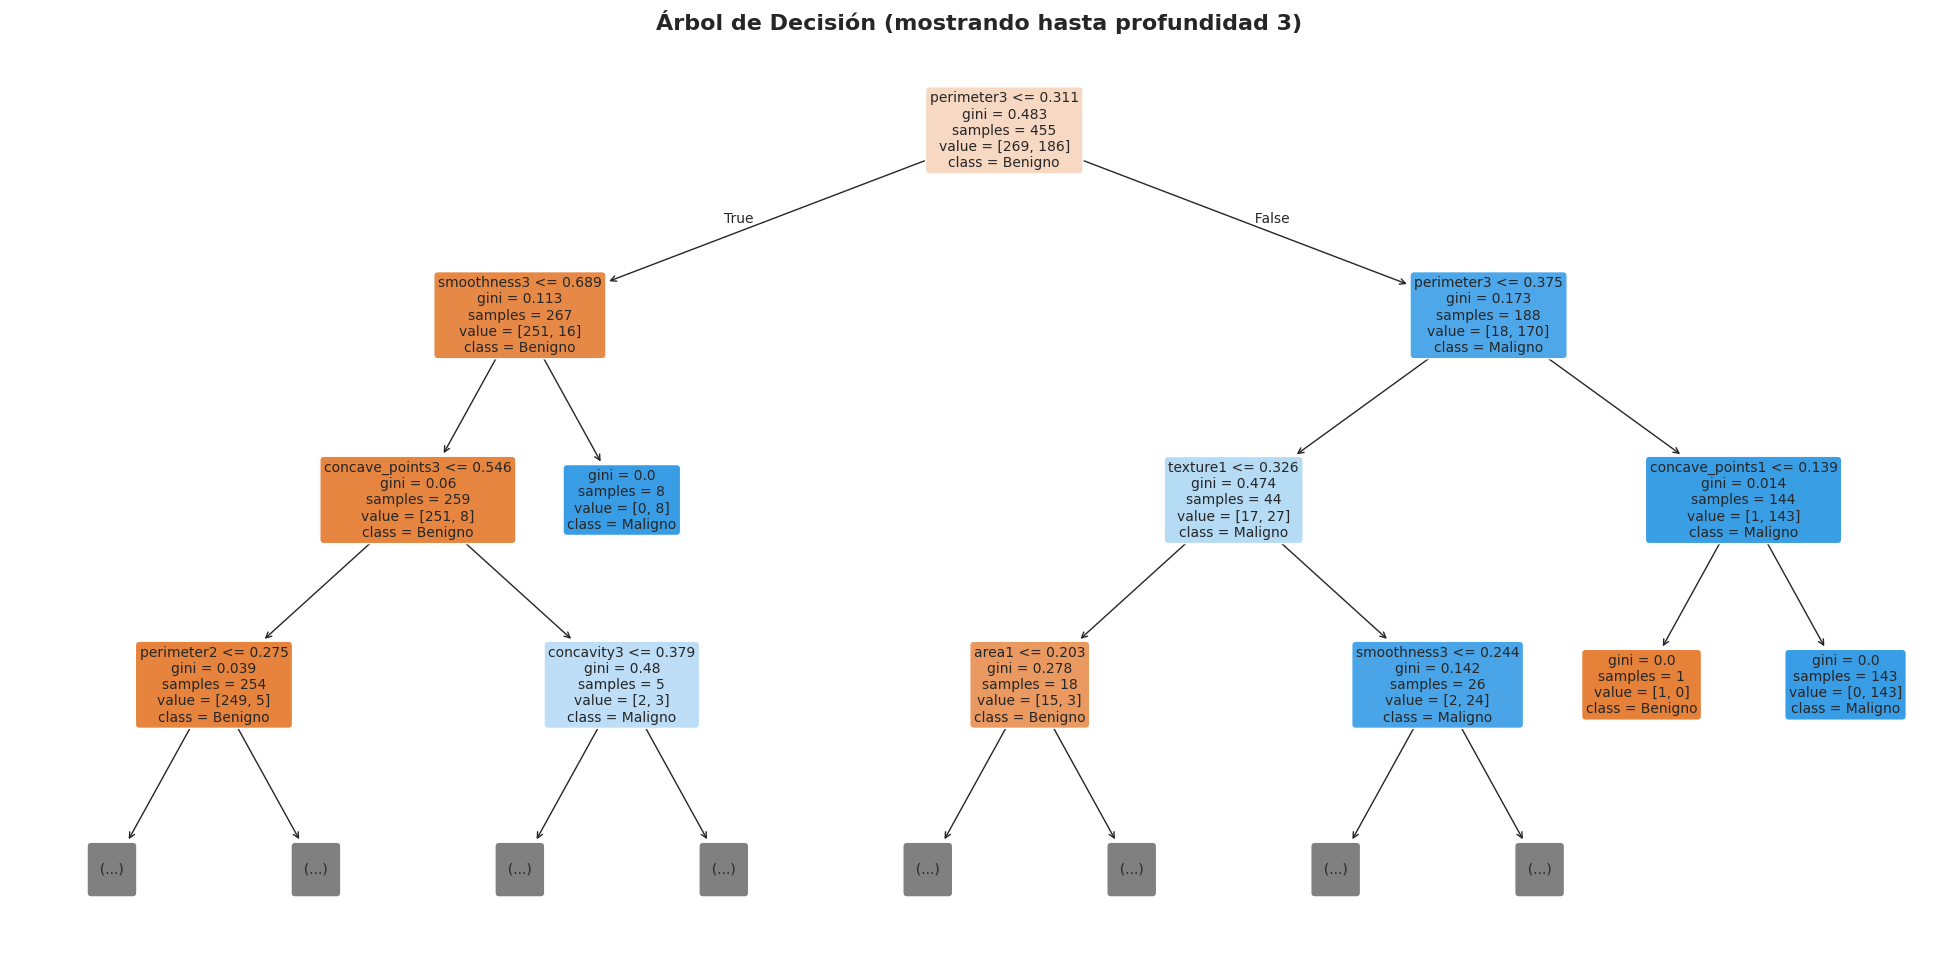

Profundidad total del árbol: 8
Número total de hojas: 17


In [25]:
# Visualizar el árbol de decisión
plt.figure(figsize=(25, 12))
plot_tree(modelo_arbol_base,
          feature_names=X_train.columns,
          class_names=['Benigno', 'Maligno'],
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=10)
plt.title('Árbol de Decisión (mostrando hasta profundidad 3)', fontsize=16, fontweight='bold')
plt.show()

print(f'Profundidad total del árbol: {modelo_arbol_base.get_depth()}')
print(f'Número total de hojas: {modelo_arbol_base.get_n_leaves()}')

#### 1.3 Modelo Mejorado - Árbol de Decisión

Se mejora el modelo limitando la profundidad del árbol y ajustando hiperparámetros para evitar sobreajuste.

=== ÁRBOL DE DECISIÓN - MEJORADO ===

Reporte de clasificación:
              precision    recall  f1-score   support

     Benigno       0.97      0.89      0.93        88
     Maligno       0.71      0.92      0.80        26

    accuracy                           0.89       114
   macro avg       0.84      0.90      0.86       114
weighted avg       0.91      0.89      0.90       114

Accuracy:  0.8947
Precision: 0.7059
Recall:    0.9231
F1-Score:  0.8000


<Figure size 700x500 with 0 Axes>

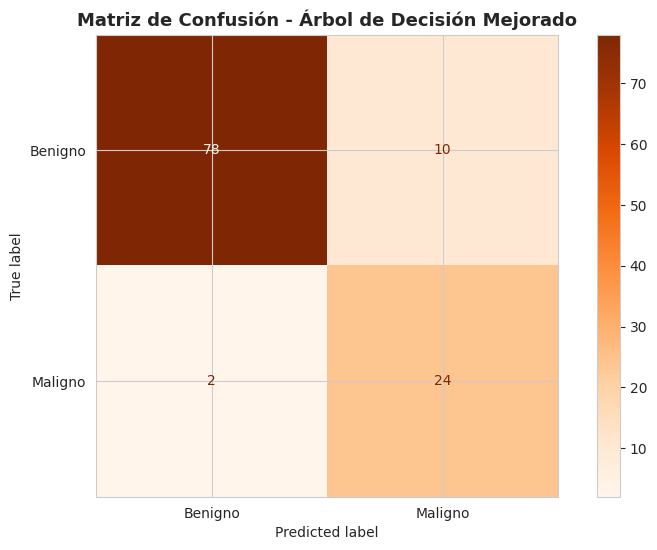

In [26]:
# Modelo mejorado con hiperparámetros ajustados
modelo_arbol_mejor = DecisionTreeClassifier(
    max_depth=4,              # Limitar profundidad del árbol
    min_samples_split=10,     # Mínimo de muestras para dividir un nodo
    min_samples_leaf=5,       # Mínimo de muestras en cada hoja
    random_state=42
)

# Entrenar
modelo_arbol_mejor.fit(X_train, y_train)

# Predecir
y_pred_arbol_mejor = modelo_arbol_mejor.predict(X_test)

# Métricas
print('=== ÁRBOL DE DECISIÓN - MEJORADO ===\n')
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred_arbol_mejor, target_names=['Benigno', 'Maligno']))

print(f'Accuracy:  {accuracy_score(y_test, y_pred_arbol_mejor):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_arbol_mejor):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_arbol_mejor):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_arbol_mejor):.4f}')

# Matriz de confusión
plt.figure(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_arbol_mejor,
                                         display_labels=['Benigno', 'Maligno'],
                                         cmap='Oranges')
plt.title('Matriz de Confusión - Árbol de Decisión Mejorado', fontsize=13, fontweight='bold')
plt.show()

#### 1.4 Interpretación - Árbol de Decisión

**Baseline:** El modelo sin restricciones obtuvo un accuracy del 85.09% con una precision baja de 62.16%, lo que indica un alto número de falsos positivos (casos benignos clasificados como malignos). Esto se debe a que el árbol sin podar creció demasiado, sobreajustándose a los datos de entrenamiento.

**Mejorado:** Al limitar la profundidad a 4 niveles y establecer un mínimo de muestras por nodo, el accuracy subió a 89.47%, la precision mejoró de 62.16% a 70.59% y el recall subió de 88.46% a 92.31%. La poda del árbol redujo el sobreajuste y mejoró la capacidad de generalización del modelo. Sin embargo, comparado con los modelos de la semana anterior (Regresión Logística y K-NN), el Árbol de Decisión muestra un rendimiento inferior.

---
### 2. Bosque Aleatorio (Random Forest)



#### 2.1 Modelo Baseline
Se implementa el Bosque Aleatorio con parámetros por defecto de Scikit-Learn.

=== BOSQUE ALEATORIO - BASELINE ===

Reporte de clasificación:
              precision    recall  f1-score   support

     Benigno       1.00      0.98      0.99        88
     Maligno       0.93      1.00      0.96        26

    accuracy                           0.98       114
   macro avg       0.96      0.99      0.98       114
weighted avg       0.98      0.98      0.98       114

Accuracy:  0.9825
Precision: 0.9286
Recall:    1.0000
F1-Score:  0.9630


<Figure size 700x500 with 0 Axes>

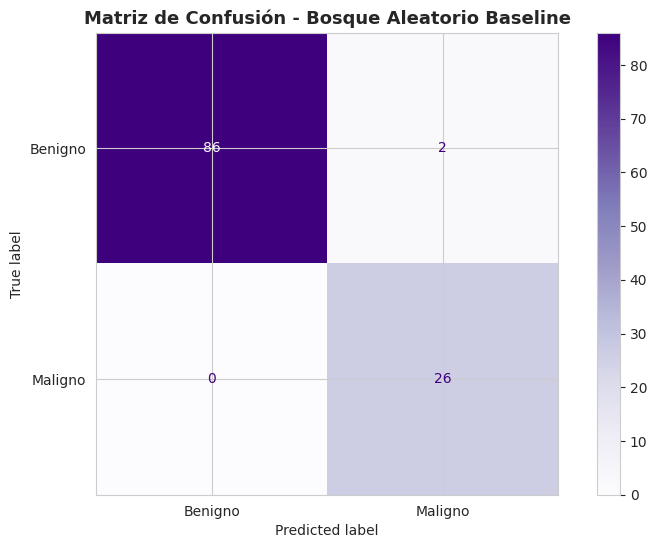

In [27]:
from sklearn.ensemble import RandomForestClassifier

# Crear modelo con parámetros por defecto
modelo_bosque_base = RandomForestClassifier(random_state=42)

# Entrenar
modelo_bosque_base.fit(X_train, y_train)

# Predecir
y_pred_bosque_base = modelo_bosque_base.predict(X_test)

# Métricas
print('=== BOSQUE ALEATORIO - BASELINE ===\n')
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred_bosque_base, target_names=['Benigno', 'Maligno']))

print(f'Accuracy:  {accuracy_score(y_test, y_pred_bosque_base):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_bosque_base):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_bosque_base):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_bosque_base):.4f}')

# Matriz de confusión
plt.figure(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_bosque_base,
                                         display_labels=['Benigno', 'Maligno'],
                                         cmap='Purples')
plt.title('Matriz de Confusión - Bosque Aleatorio Baseline', fontsize=13, fontweight='bold')
plt.show()

#### 2.2 Modelo Mejorado - Bosque Aleatorio

Se mejora el modelo ajustando el número de árboles y los hiperparámetros de cada árbol individual.

=== BOSQUE ALEATORIO - MEJORADO ===

Reporte de clasificación:
              precision    recall  f1-score   support

     Benigno       1.00      0.97      0.98        88
     Maligno       0.90      1.00      0.95        26

    accuracy                           0.97       114
   macro avg       0.95      0.98      0.96       114
weighted avg       0.98      0.97      0.97       114

Accuracy:  0.9737
Precision: 0.8966
Recall:    1.0000
F1-Score:  0.9455


<Figure size 700x500 with 0 Axes>

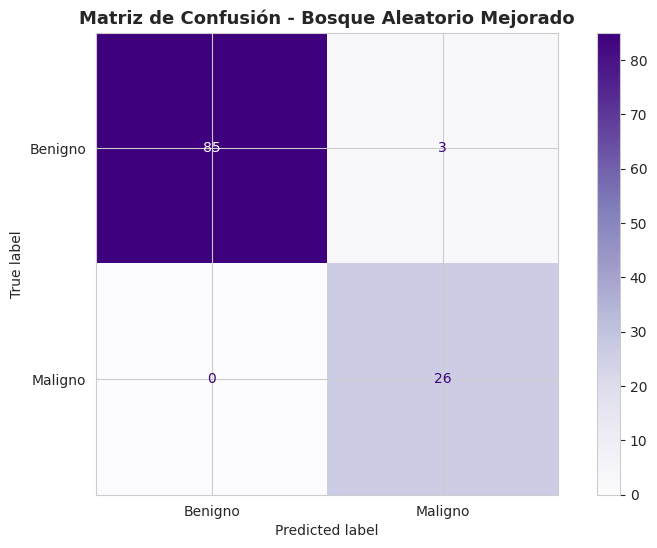

In [28]:
# Modelo mejorado con hiperparámetros ajustados
modelo_bosque_mejor = RandomForestClassifier(
    n_estimators=200,         # 200 árboles en vez de 100 (default)
    max_depth=6,              # Limitar profundidad de cada árbol
    min_samples_split=5,      # Mínimo de muestras para dividir
    min_samples_leaf=2,       # Mínimo de muestras en cada hoja
    random_state=42
)

# Entrenar
modelo_bosque_mejor.fit(X_train, y_train)

# Predecir
y_pred_bosque_mejor = modelo_bosque_mejor.predict(X_test)

# Métricas
print('=== BOSQUE ALEATORIO - MEJORADO ===\n')
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred_bosque_mejor, target_names=['Benigno', 'Maligno']))

print(f'Accuracy:  {accuracy_score(y_test, y_pred_bosque_mejor):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_bosque_mejor):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_bosque_mejor):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_bosque_mejor):.4f}')

# Matriz de confusión
plt.figure(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_bosque_mejor,
                                         display_labels=['Benigno', 'Maligno'],
                                         cmap='Purples')
plt.title('Matriz de Confusión - Bosque Aleatorio Mejorado', fontsize=13, fontweight='bold')
plt.show()

#### 2.3 Interpretación - Bosque Aleatorio

**Baseline:** El modelo con parámetros por defecto (100 árboles) obtuvo un excelente rendimiento con un accuracy del 98.25% y un recall perfecto del 100%, detectando todos los casos malignos. La precision fue de 92.86%, con solo 2 falsos positivos.

**Mejorado:** Al aumentar a 200 árboles y limitar la profundidad a 6 niveles, el accuracy bajó ligeramente a 97.37% y la precision a 89.66%, aunque el recall se mantuvo en 100%. Esto indica que los parámetros por defecto de Random Forest ya estaban bien optimizados para este dataset, y la restricción de profundidad limitó la capacidad del modelo sin aportar mejoras.

**Conclusión:** El Bosque Aleatorio demostró ser significativamente superior al Árbol de Decisión individual, confirmando que la combinación de múltiples árboles reduce el sobreajuste y mejora la generalización.

---
### 3. Red Neuronal Artificial (TensorFlow-Keras)



#### 3.1 Construcción y entrenamiento del modelo

In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Construir la red neuronal
modelo_rna = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),  # Capa oculta 1: 32 neuronas
    Dense(16, activation='relu'),                                    # Capa oculta 2: 16 neuronas
    Dense(1, activation='sigmoid')                                   # Capa de salida: 1 neurona (0 o 1)
])

# Compilar el modelo
modelo_rna.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# Resumen de la arquitectura
modelo_rna.summary()

# Entrenar el modelo
historial = modelo_rna.fit(X_train, y_train,
                           epochs=100,
                           batch_size=16,
                           validation_data=(X_test, y_test),
                           verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4747 - loss: 0.6579 - val_accuracy: 0.6579 - val_loss: 0.6532
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8176 - loss: 0.5954 - val_accuracy: 0.7456 - val_loss: 0.5935
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8857 - loss: 0.5229 - val_accuracy: 0.7982 - val_loss: 0.5273
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8989 - loss: 0.4375 - val_accuracy: 0.8947 - val_loss: 0.4083
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9165 - loss: 0.3601 - val_accuracy: 0.9211 - val_loss: 0.3187
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9121 - loss: 0.2985 - val_accuracy: 0.9035 - val_loss: 0.2959
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9165 - loss: 0.2540 - val_accuracy: 0.8860 - val_loss: 0.2946
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9253 - loss: 0.2223 - val_accuracy: 0.9474 - v

#### 3.2 Curvas de Aprendizaje (Loss y Accuracy)

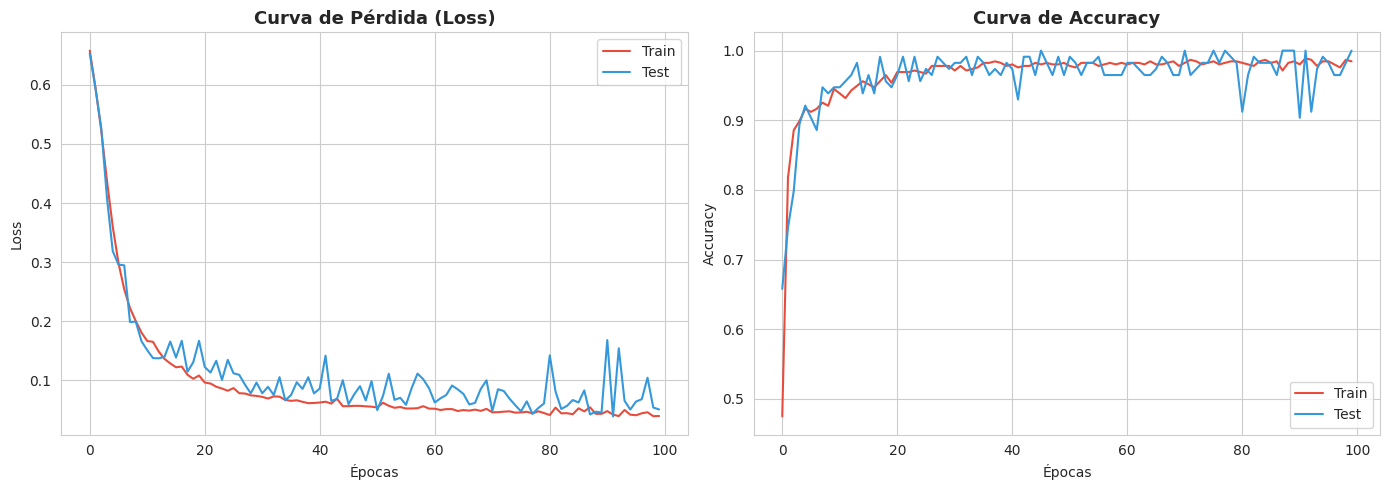

In [30]:
# --- Curvas de aprendizaje ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de Loss
axes[0].plot(historial.history['loss'], label='Train', color='#e74c3c')
axes[0].plot(historial.history['val_loss'], label='Test', color='#3498db')
axes[0].set_title('Curva de Pérdida (Loss)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Curva de Accuracy
axes[1].plot(historial.history['accuracy'], label='Train', color='#e74c3c')
axes[1].plot(historial.history['val_accuracy'], label='Test', color='#3498db')
axes[1].set_title('Curva de Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

#### 3.3 Evaluación de la Red Neuronal

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
=== RED NEURONAL ARTIFICIAL ===

Reporte de clasificación:
              precision    recall  f1-score   support

     Benigno       1.00      1.00      1.00        88
     Maligno       1.00      1.00      1.00        26

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114

Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000


<Figure size 700x500 with 0 Axes>

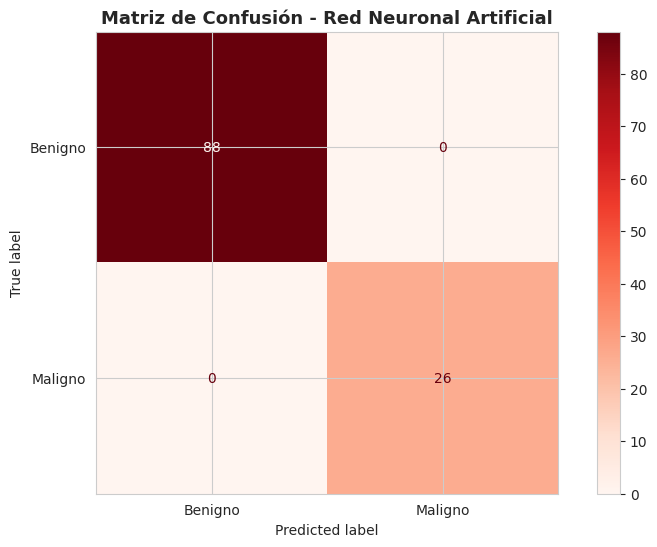

In [31]:
# Predecir (la red neuronal devuelve probabilidades, convertimos a 0 o 1)
y_pred_rna_prob = modelo_rna.predict(X_test)
y_pred_rna = (y_pred_rna_prob > 0.5).astype(int).flatten()

# Métricas
print('=== RED NEURONAL ARTIFICIAL ===\n')
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred_rna, target_names=['Benigno', 'Maligno']))

print(f'Accuracy:  {accuracy_score(y_test, y_pred_rna):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rna):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_rna):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_rna):.4f}')

# Matriz de confusión
plt.figure(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rna,
                                         display_labels=['Benigno', 'Maligno'],
                                         cmap='Reds')
plt.title('Matriz de Confusión - Red Neuronal Artificial', fontsize=13, fontweight='bold')
plt.show()

#### 3.4 Interpretación - Red Neuronal Artificial

La red neuronal obtuvo un rendimiento perfecto con un accuracy, precision, recall y F1-Score del 100%, clasificando correctamente todos los casos de prueba. Las curvas de aprendizaje muestran que el modelo convergió rápidamente (alrededor de la época 20) y se mantuvo estable sin señales de sobreajuste, con las curvas de entrenamiento y prueba siguiendo trayectorias similares. Este resultado demuestra la capacidad de las redes neuronales para capturar relaciones complejas y no lineales entre las variables, superando a todos los modelos anteriores.

---
### 4. Comparación de Todos los Algoritmos

=== COMPARACIÓN DE TODOS LOS MODELOS ===

             Modelo  Accuracy  Precision  Recall  F1-Score
        LR Baseline    0.9737     0.9600  0.9231    0.9412
        LR Mejorado    0.9649     0.9231  0.9231    0.9231
 KNN Baseline (K=5)    0.9649     0.8667  1.0000    0.9286
KNN Mejorado (K=10)    0.9912     0.9630  1.0000    0.9811
     Árbol Baseline    0.8509     0.6216  0.8846    0.7302
     Árbol Mejorado    0.8947     0.7059  0.9231    0.8000
    Bosque Baseline    0.9825     0.9286  1.0000    0.9630
    Bosque Mejorado    0.9737     0.8966  1.0000    0.9455
       Red Neuronal    1.0000     1.0000  1.0000    1.0000


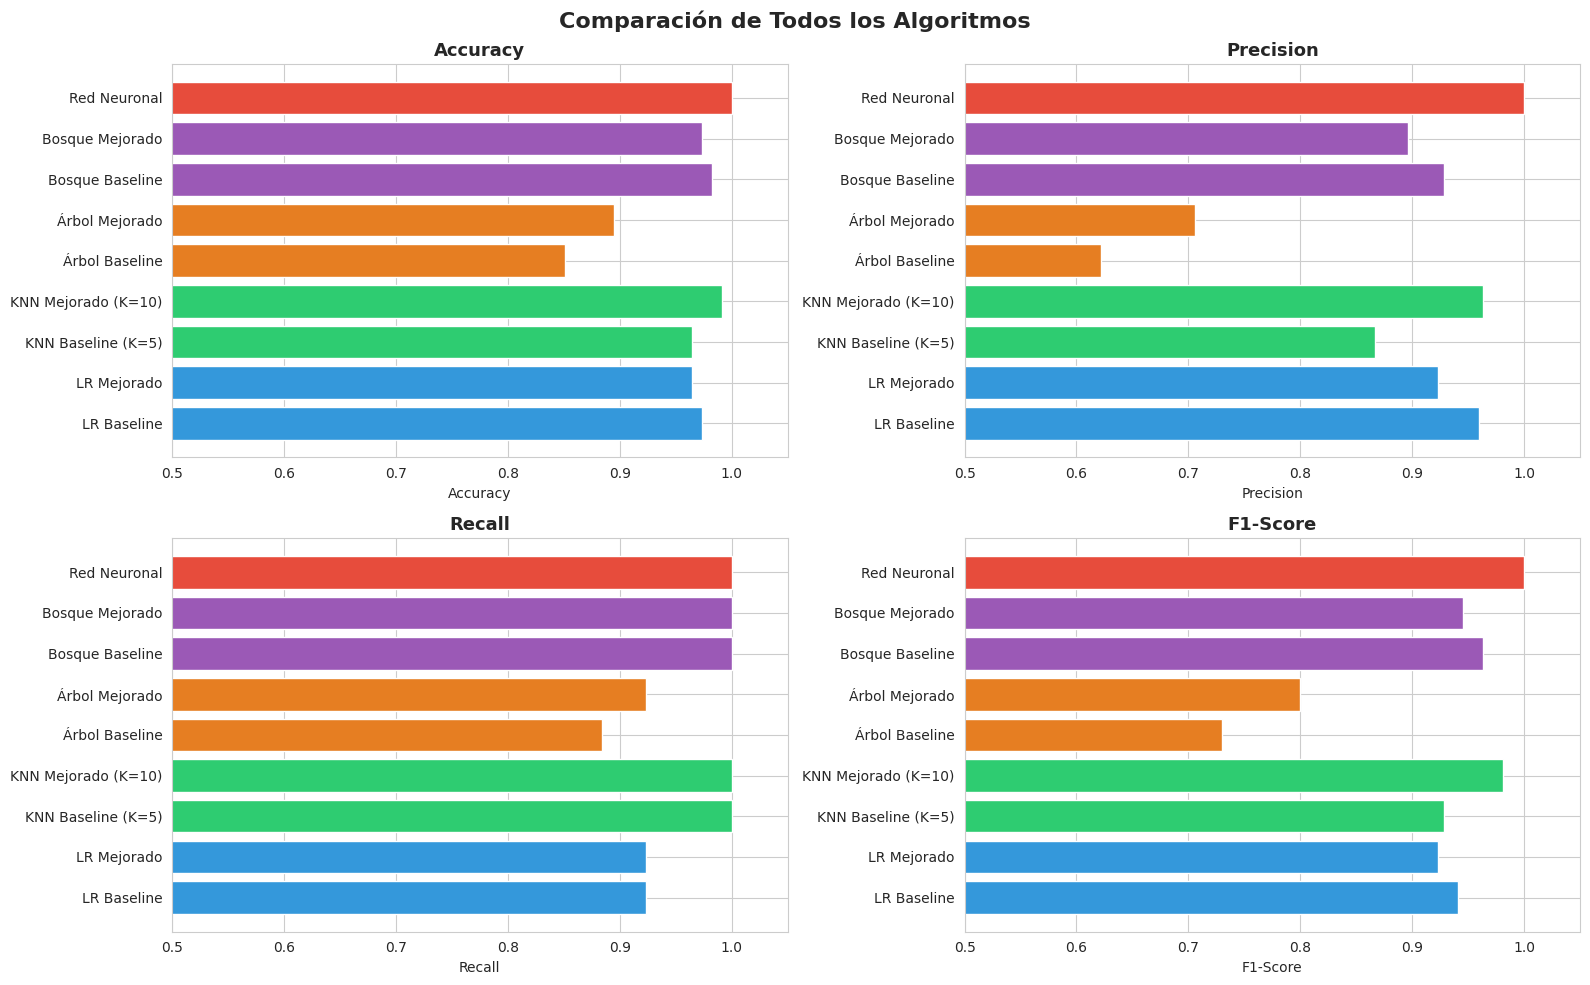

In [32]:
# Tabla comparativa de TODOS los modelos
todos_los_modelos = pd.DataFrame({
    'Modelo': ['LR Baseline', 'LR Mejorado',
               'KNN Baseline (K=5)', 'KNN Mejorado (K=10)',
               'Árbol Baseline', 'Árbol Mejorado',
               'Bosque Baseline', 'Bosque Mejorado',
               'Red Neuronal'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr_base),
        accuracy_score(y_test, y_pred_lr_mejor),
        accuracy_score(y_test, y_pred_knn_base),
        accuracy_score(y_test, y_pred_knn_mejor),
        accuracy_score(y_test, y_pred_arbol_base),
        accuracy_score(y_test, y_pred_arbol_mejor),
        accuracy_score(y_test, y_pred_bosque_base),
        accuracy_score(y_test, y_pred_bosque_mejor),
        accuracy_score(y_test, y_pred_rna)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr_base),
        precision_score(y_test, y_pred_lr_mejor),
        precision_score(y_test, y_pred_knn_base),
        precision_score(y_test, y_pred_knn_mejor),
        precision_score(y_test, y_pred_arbol_base),
        precision_score(y_test, y_pred_arbol_mejor),
        precision_score(y_test, y_pred_bosque_base),
        precision_score(y_test, y_pred_bosque_mejor),
        precision_score(y_test, y_pred_rna)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr_base),
        recall_score(y_test, y_pred_lr_mejor),
        recall_score(y_test, y_pred_knn_base),
        recall_score(y_test, y_pred_knn_mejor),
        recall_score(y_test, y_pred_arbol_base),
        recall_score(y_test, y_pred_arbol_mejor),
        recall_score(y_test, y_pred_bosque_base),
        recall_score(y_test, y_pred_bosque_mejor),
        recall_score(y_test, y_pred_rna)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr_base),
        f1_score(y_test, y_pred_lr_mejor),
        f1_score(y_test, y_pred_knn_base),
        f1_score(y_test, y_pred_knn_mejor),
        f1_score(y_test, y_pred_arbol_base),
        f1_score(y_test, y_pred_arbol_mejor),
        f1_score(y_test, y_pred_bosque_base),
        f1_score(y_test, y_pred_bosque_mejor),
        f1_score(y_test, y_pred_rna)
    ]
})

todos_los_modelos = todos_los_modelos.round(4)
print('=== COMPARACIÓN DE TODOS LOS MODELOS ===\n')
print(todos_los_modelos.to_string(index=False))

# --- Bar Chart comparativo ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Comparación de Todos los Algoritmos', fontsize=16, fontweight='bold')

metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colores = ['#3498db', '#3498db', '#2ecc71', '#2ecc71', '#e67e22', '#e67e22', '#9b59b6', '#9b59b6', '#e74c3c']

for i, metrica in enumerate(metricas):
    ax = axes[i // 2, i % 2]
    ax.barh(todos_los_modelos['Modelo'], todos_los_modelos[metrica], color=colores)
    ax.set_xlabel(metrica)
    ax.set_title(metrica, fontsize=13, fontweight='bold')
    ax.set_xlim(0.5, 1.05)

plt.tight_layout()
plt.show()

---
### 5. Conclusiones Generales - Semana 3

1. **Red Neuronal Artificial** obtuvo el mejor rendimiento de todos los algoritmos con un accuracy, precision, recall y F1-Score del 100%, demostrando su capacidad para capturar relaciones complejas entre las variables.

2. **Bosque Aleatorio** fue el segundo mejor modelo con un accuracy del 98.25% y recall del 100% en su versión baseline. La combinación de múltiples árboles demostró ser muy superior a un Árbol de Decisión individual.

3. **Árbol de Decisión** tuvo el rendimiento más bajo (85.09% baseline), pero mejoró significativamente con la poda de hiperparámetros (89.47%). Esto confirma que un solo árbol sin restricciones tiende a sobreajustarse.

4. **K-NN Mejorado (K=10)** sigue siendo un modelo competitivo con 99.12% de accuracy y recall perfecto, siendo más simple de implementar que una red neuronal.

5. **En un contexto médico**, la Red Neuronal y el Bosque Aleatorio serían los modelos más recomendados para la predicción de cáncer de mama, ya que ambos lograron un recall del 100%, asegurando que ningún caso maligno se quede sin detectar y sea un falso negativo lo cual puede ser muy riesgoso en el tratamiento y pronta deteccióin del cáncer.

---
### Aplicación en campo profesional Semana 3

1. **Santiago Calle:** Como ingeniero mecatrónico, estos algoritmos pueden aplicarse al mantenimiento predictivo industrial. Un Árbol de Decisión permite generar reglas interpretables para diagnosticar fallas en equipos, facilitando que los técnicos entiendan la lógica de las alertas. El Bosque Aleatorio, al combinar múltiples árboles, ofrece mayor precisión en la predicción de fallas al considerar simultáneamente variables como temperatura, corriente, presión y tiempos de operación. La Red Neuronal Artificial puede detectar patrones complejos y no evidentes en los datos de sensores, anticipando fallas antes de que ocurran. La comparación de modelos realizada en esta práctica es directamente aplicable para seleccionar el algoritmo más adecuado según la complejidad del sistema industrial a monitorear.

2. **Alexander Luna:** En el Registro de la Propiedad, los algoritmos de esta semana ofrecen distintos niveles de sofisticación para la detección de irregularidades. Un Árbol de Decisión genera reglas transparentes que pueden auditarse legalmente, como: si el cambio de propietario es en menos de 30 días y el valor declarado es inferior al avalúo catastral, la transacción es sospechosa. El Bosque Aleatorio mejora la detección combinando múltiples criterios y reduciendo falsos positivos. La Red Neuronal Artificial puede identificar patrones de fraude complejos que no son evidentes con reglas simples, analizando simultáneamente todas las variables de una transacción. Como se demostró en la práctica, mientras más complejo es el modelo, mayor es su capacidad de detección, priorizando siempre el recall para que ninguna irregularidad pase sin ser identificada.

3. **Alvaro Quisilema:** Como ingeniero mecatrónico, los algoritmos estudiados esta semana tienen aplicación directa en el control de calidad de procesos de manufactura. Un Árbol de Decisión puede utilizarse para crear reglas claras e interpretables de inspección, como: si la vibración supera cierto umbral y la temperatura está fuera de rango, la pieza es defectuosa. El Bosque Aleatorio mejora esta clasificación combinando múltiples criterios simultáneamente, reduciendo errores de inspección. La Red Neuronal Artificial puede capturar relaciones complejas y no lineales entre variables de producción que los modelos más simples no detectan, permitiendo un control de calidad más preciso. Tal como se demostró en esta práctica, la Red Neuronal obtuvo el mejor rendimiento, lo que sugiere su potencial para sistemas de inspección automatizada donde la precisión es crítica